In [1]:
###exercise from wiki :D, process on doc later:)

#constants
import numpy as np
import matplotlib.pyplot as plt

#cam measurements from wikiiii
width=512
height=140
#pixels
pixel_size=16e-6 
# magnification (x2?)
magnification = 2


pix_size_atoms=pixel_size/magnification
pix_area=pix_size_atoms**2 

imaging_wavelength= 460.8e-9

sigma0=3*imaging_wavelength**2/(2*np.pi) #resonant cross section




In [2]:
def load_image(filename): 
    image = np.fromfile(filename, dtype=np.float32)
    image = image[1::2]
    image = image.reshape(height, width)*2


    return image

In [3]:
###imagessss
atom = load_image("atom.bin")
reference= load_image("reference.bin")
dark = load_image("dark.bin")

In [4]:
#equations:))))
#optical density yeyeyeye


eps= 1e-10

I_atom= atom-dark
I_ref= reference-dark

#this just prevents math error
#since smallest not - or 0 cuz of the ln
valid_pixels = (I_atom > eps) & (I_ref > eps)

Optical_density = np.zeros_like(I_atom)
Optical_density[valid_pixels] = np.log(I_ref[valid_pixels] / I_atom[valid_pixels])
#Since it says to limit 
Optical_density= np.clip(Optical_density, 0, 5)

In [5]:
#region of interest (ROI)
#x1, x2 = 100,  400
#y1, y2 = 0, 100

#ROI = Optical_density[y1:y2, x1:x2]



In [6]:
#region of interest (ROI)

from scipy.ndimage import gaussian_filter

#taking center and max to get upper and lower bound
def clipped_range(center, margin, max_value):
    lo = np.clip(center - margin, 0, max_value)
    hi = np.clip(center + margin, 0, max_value)
    return lo, hi

#smoothhhhh to locate the peak
smoothed_od = gaussian_filter(Optical_density, sigma=3)
row_max, col_max = np.unravel_index(np.argmax(smoothed_od), smoothed_od.shape)


#extending the box 
rows_up_down = 30
cols_left_right = 50

y1, y2 = clipped_range(row_max, rows_up_down, Optical_density.shape[0])
x1, x2 = clipped_range(col_max, cols_left_right, Optical_density.shape[1])

ROI = Optical_density[y1:y2, x1:x2]


In [7]:
print("x1, x2:", x1, x2)  
print("y1, y2:", y1, y2)

x1, x2: 155 255
y1, y2: 0 48


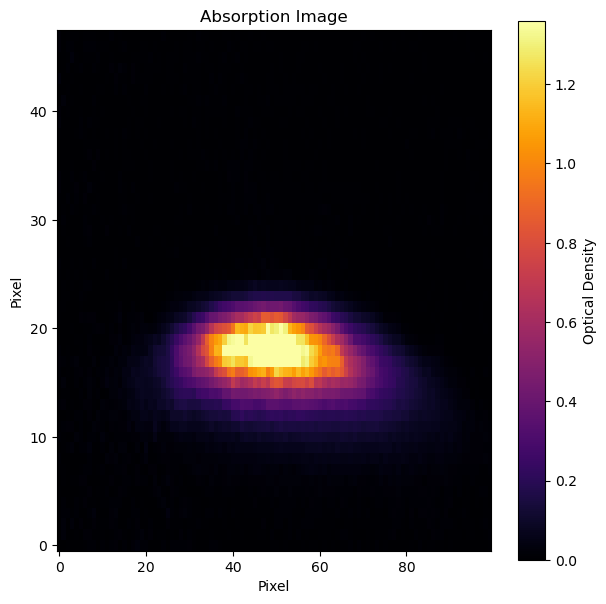

In [8]:
#the image O_o 

plt.figure(figsize=(7,7))

positive_od = Optical_density[Optical_density > 0]
vmax_display = np.percentile(positive_od, 99) if positive_od.size else 1

plt.imshow(
    ROI,
    cmap='inferno',
    origin='lower',
    vmin=0,
    vmax=np.percentile(ROI[ROI > 0], 99),
    aspect= 2.5

)

plt.colorbar(label="Optical Density")

plt.xlabel("Pixel")
plt.ylabel("Pixel")

plt.title("Absorption Image")

plt.show()

In [9]:
#number of atoms 
N_atoms = np.sum(ROI) * pix_area / sigma0

print(f"Estimated atom number = {N_atoms:.3e}")

Estimated atom number = 2.436e+05
